Run the following code once to get the dataframe:

In [39]:
from PullData import pull_data_from_supabase
import pandas as pd
import seaborn  as sns
import matplotlib.pyplot as plt
import numpy as np
df = pull_data_from_supabase()

print(df.info())


feature_cols = ["learning_rate","batch_size","buffer_size","hidden_units","num_layers","time_horizon","beta","gamma","lambd","max_steps"]
target_cols = ["final_10_percent_reward_mean","late_phase_std"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2261 entries, 0 to 2260
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   run_id                        2261 non-null   object 
 1   learning_rate                 2261 non-null   float64
 2   batch_size                    2261 non-null   int64  
 3   buffer_size                   2261 non-null   int64  
 4   hidden_units                  2261 non-null   int64  
 5   num_layers                    2261 non-null   int64  
 6   time_horizon                  2261 non-null   int64  
 7   beta                          2261 non-null   float64
 8   gamma                         2261 non-null   float64
 9   lambd                         2261 non-null   float64
 10  final_10_percent_reward_mean  2261 non-null   float64
 11  mean_reward                   2261 non-null   float64
 12  max_reward                    2261 non-null   float64
 13  min

### Features:
- learning_rate 
- batch_size 
- buffer_size 
- hidden_units 
- num_layers 
- time_horizon 
- beta 
- gamma 
- lambd 
- max_steps 

### Targets:
- final_10_percent_reward_mean
- late_phase_std

## Tasks:
1) Dataset Overview (Person A)
- Count total rows
- Count rows where error_occurred = true 
- Count rows where convergence_detected = true 
- List columns with missing values and counts 

Deliverable: table of counts

In [108]:

total_records = len(df)
total_error_records = (df['error_occurred'] == True).sum()
total_records_converged = (df['convergence_detected'] == True).sum()
columns_with_nulls = df.columns[df.isna().any()].tolist()
null_columns_count = len(columns_with_nulls)


overview_table = pd.DataFrame({
    'total_records': [total_records],
    'total_error_records': [total_error_records],
    'total_records_converged': [total_records_converged],
    'columns_with_nulls_count': [null_columns_count],
    'columns_with_nulls_list': [', '.join(columns_with_nulls) if columns_with_nulls else 'None']
})

display(overview_table.style
    .set_caption('Dataset Overview ')
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', "#000000"), ('color', 'white')]},
        {'selector': 'td', 'props': [('background-color', '#FFFFFF'), ('color', 'black')]},
        {'selector': 'table', 'props': [('border', '1px solid #dddddd')]}
    ])
    .hide(axis="index")
)

total_records,total_error_records,total_records_converged,columns_with_nulls_count,columns_with_nulls_list
2261,0,2261,2,"config_path, error_message"


2) Feature Distribution (Person C)
- Plot normal Histogram for: hidden_units, num_layers, time_horizon, gamma, lambd, max_steps
- Plot Histogram with Log Scale for: learning_rate, batch_size, buffer_size, and beta
- x-axis: value of the feature
- y-axis: count/frequency

Deliverable: 6 normal histograms, 4 histograms with log scale

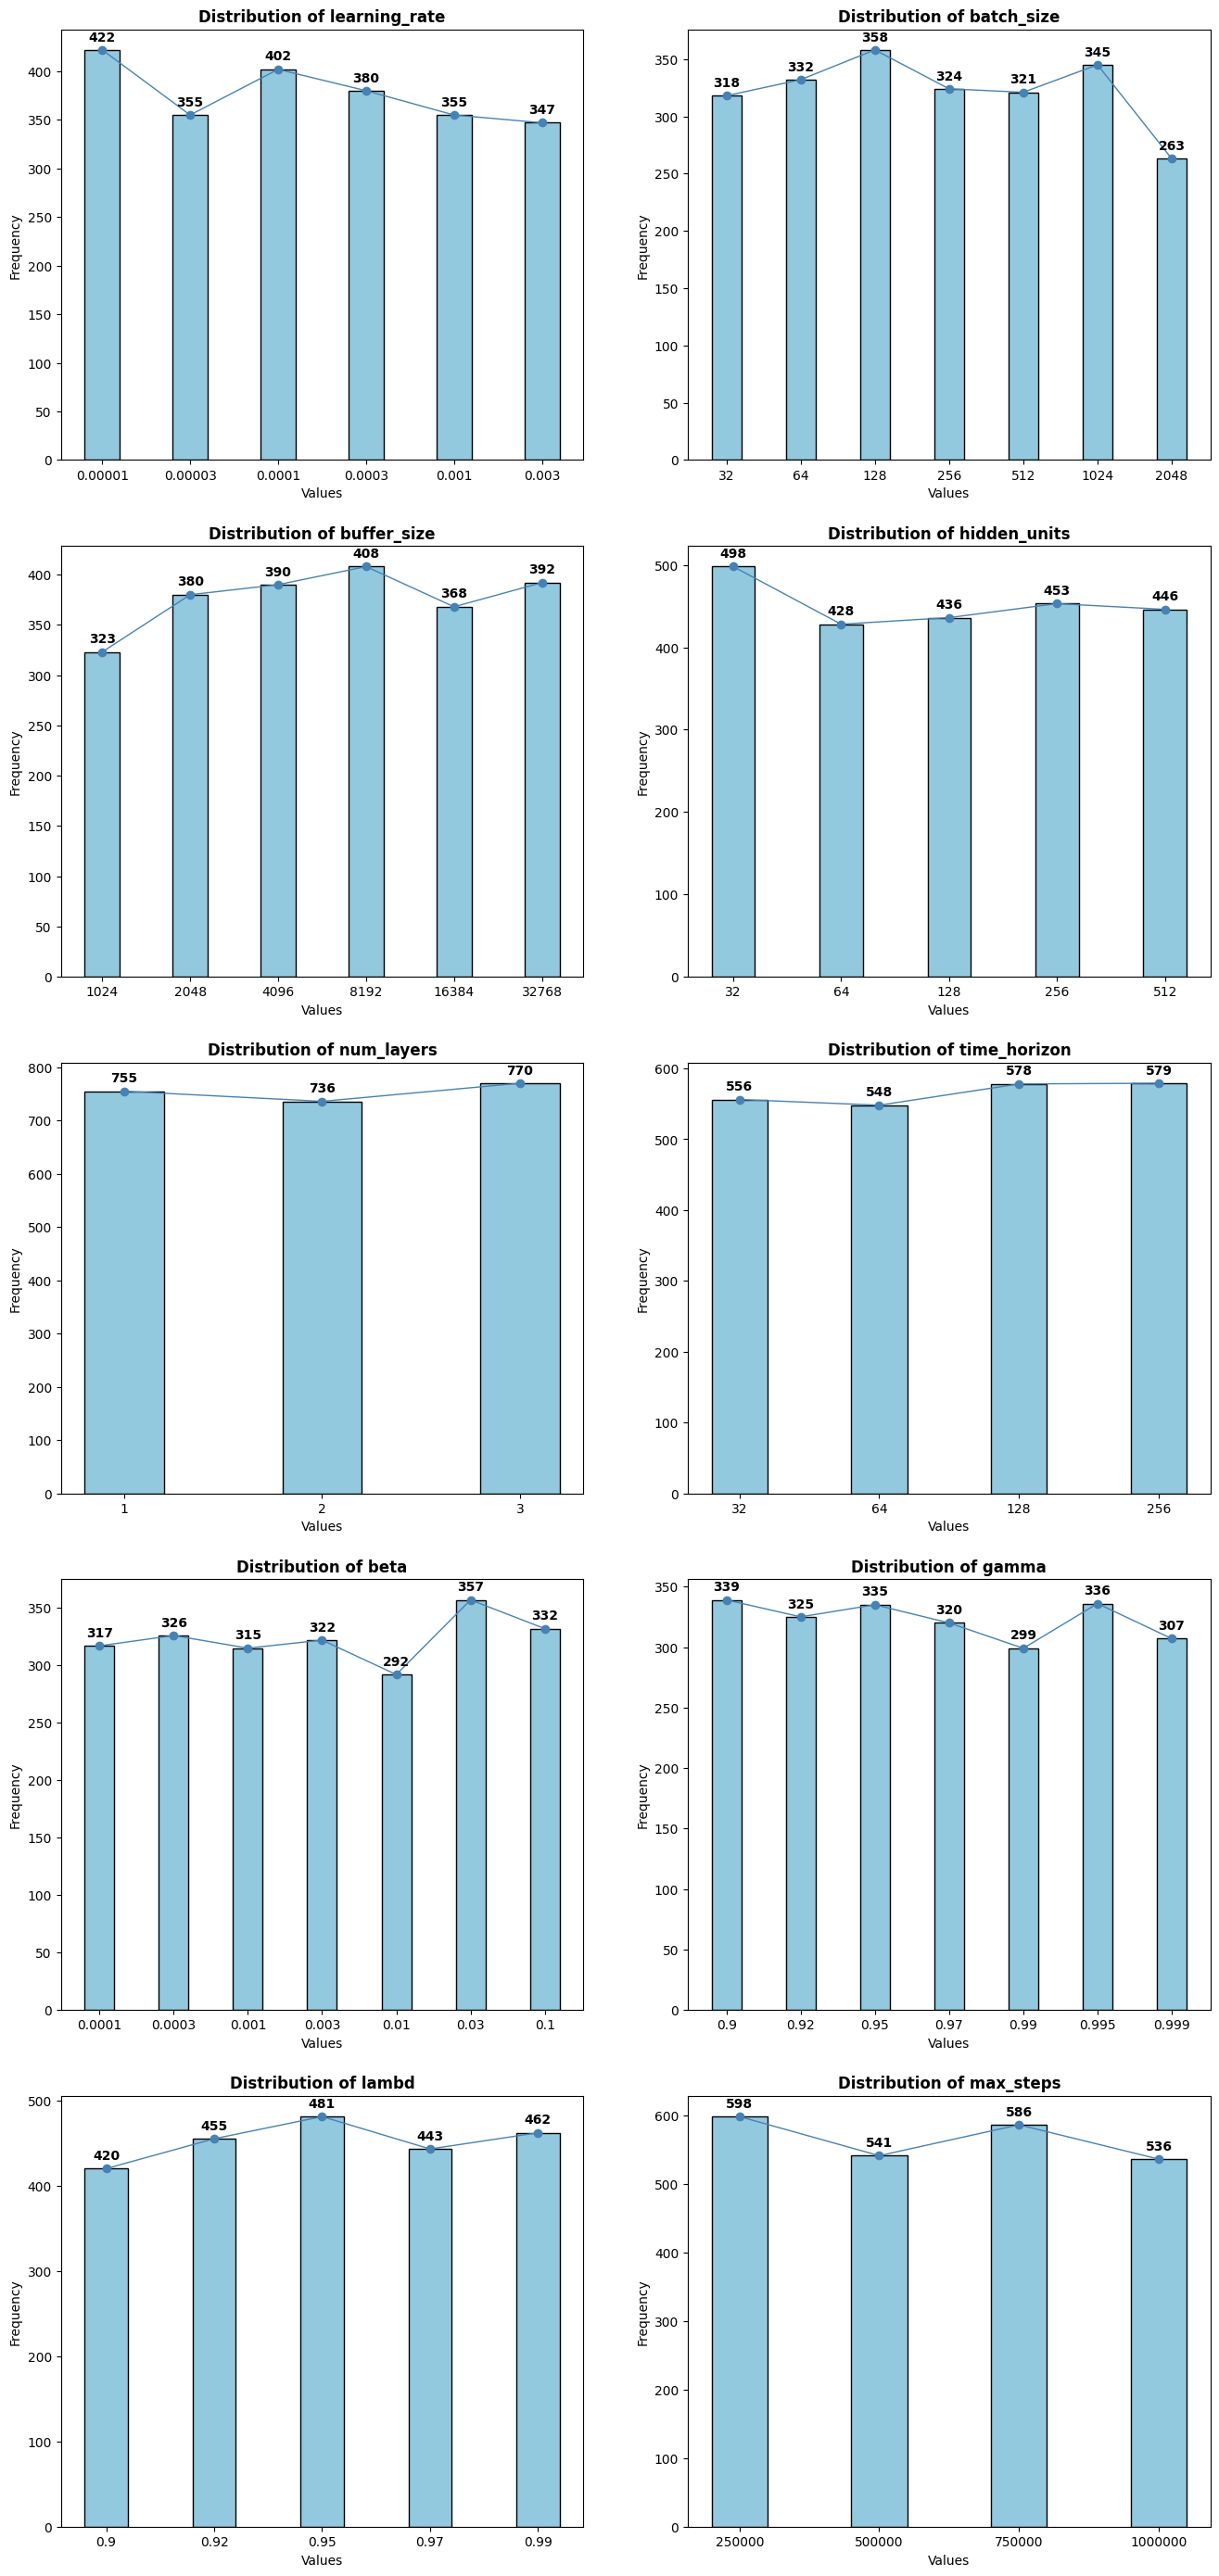

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [ ]:
features = feature_cols


fig, axes = plt.subplots(5, 2, figsize=(16, 35))
axes = axes.flatten()  

for i, col in enumerate(features):

    plot = axes[i]
    counts = df[col].value_counts().sort_index()

    formatted_labels = [f"{val:f}".rstrip('0').rstrip('.') if '.' in f"{val:f}" else f"{val:f}" for val in counts.index]
    ## This is to make the value show full decimal number e.g., 0.00001, not 1e-05
    
    plt.figure(figsize=(8, 4))

    ## These are for histogram, but it does not look reasonable 
    # num_bins = df[col].nunique()
    # sns.histplot(df[col],discrete=True, bins=num_bins)


    sns.barplot(x=formatted_labels, y=counts.values, ax=plot,width=0.4, color="skyblue",edgecolor='black')
    


    # trend line
    plot.plot(range(len(counts)), counts.values, color='steelblue', marker='o', linewidth=1)

    #Add data labels on top of each bar
    for bar in plot.patches:
        height = bar.get_height()
        plot.annotate(f'{int(height)}', 
                    (bar.get_x() + bar.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')
    
    plot.set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    plot.set_ylabel("Frequency")
    plot.set_xlabel("Values")


plt.subplots_adjust(hspace=0.8, wspace=0.3)
plt.show()

3. Target Distribution (Person C)
- Plot histogram for each target
  - x-axis: should be ranges of values (bins)
  - y-axis: count/frequency
- Plot boxplot for each target:
  - x-axis: also should be ranges of values 

Deliverable: 2 histograms, 2 boxplots

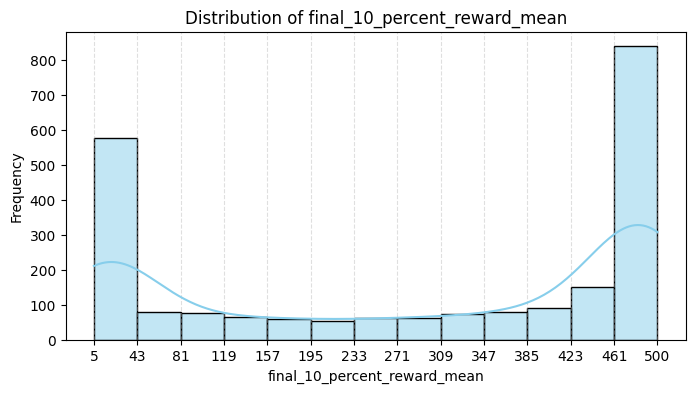

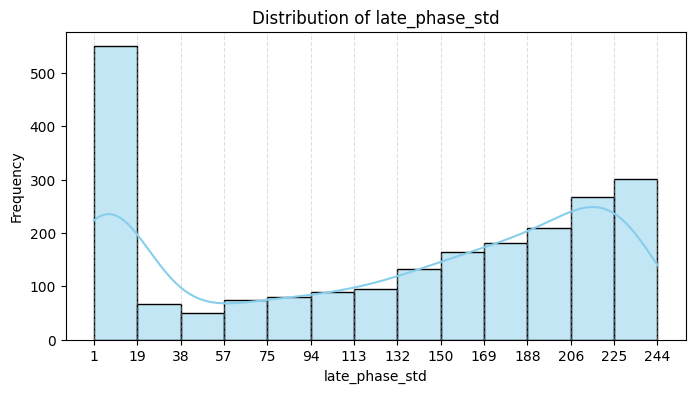

In [ ]:

targets = target_cols

for col in targets:
    plt.figure(figsize=(8, 4))

    plot = sns.histplot(df[col], kde=True, color='skyblue', edgecolor='black')

    ## Ensure the value label positioned at the begining of each bar
    edges = [bar.get_x() for bar in plot.patches] 
    last_bar = plot.patches[-1]
    edges.append(last_bar.get_x() + last_bar.get_width())

    plt.xticks(edges, labels=[int(x) for x in edges])
    plt.grid(axis='x', linestyle='--', alpha=0.4)


    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

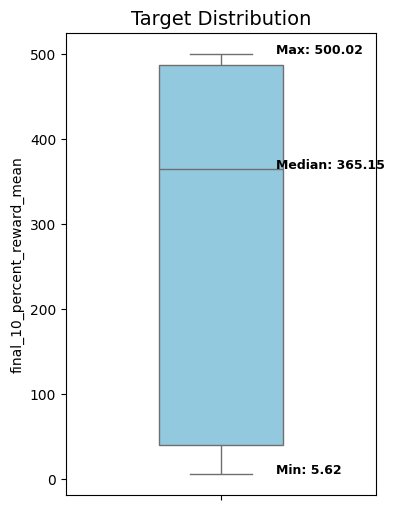

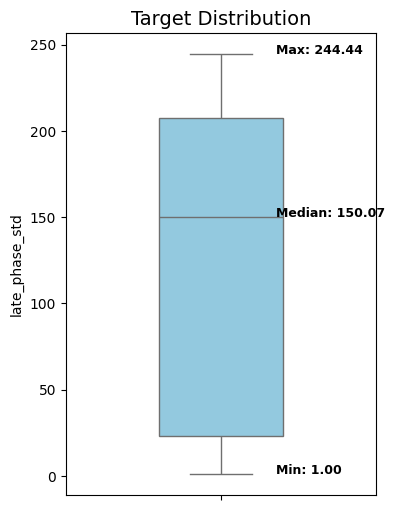

In [107]:

targets = target_cols


for target in targets:
    actual_min = df[target].min()
    actual_max = df[target].max()
    actual_median = df[target].median()

    plt.figure(figsize=(4, 6))
    plot = sns.boxplot(y=df[target], color='skyblue', width=0.4)


    plot.annotate(f'Max: {actual_max:.2f}', 
                xy=(0, actual_max), xytext=(40, 0), 
                textcoords='offset points',
                fontsize=9, fontweight='bold')

    plot.annotate(f'Median: {actual_median:.2f}', 
                xy=(0, actual_median), xytext=(40, 0), 
                textcoords='offset points',
                fontsize=9, fontweight='bold')

    plot.annotate(f'Min: {actual_min:.2f}', 
                xy=(0, actual_min), xytext=(40, 0), 
                textcoords='offset points',
                fontsize=9, fontweight='bold')

    plt.title(f"Target Distribution", fontsize=14)
    plt.ylabel(f"{target}")
    plt.show()

4. Feature vs Target (Person B)
- To see how every feature affects the agent's success.
- For each feature:
    - Plot a scatter vs `final_10_percent_reward_mean`
    - Plot a scatter vs `late_phase_std`
    - x-axis: should be the feature
    - y-axis: should be the target
- Note: We often have **Overplotting**. This happens when many runs use the exact same hyperparameter value, causing the dots to stack on top of each other into one solid blob. The fix: Setting an `alpha` value

Deliverable: 2 scatter plots for each feature (10 features x 2 targets = 20 plots in total)


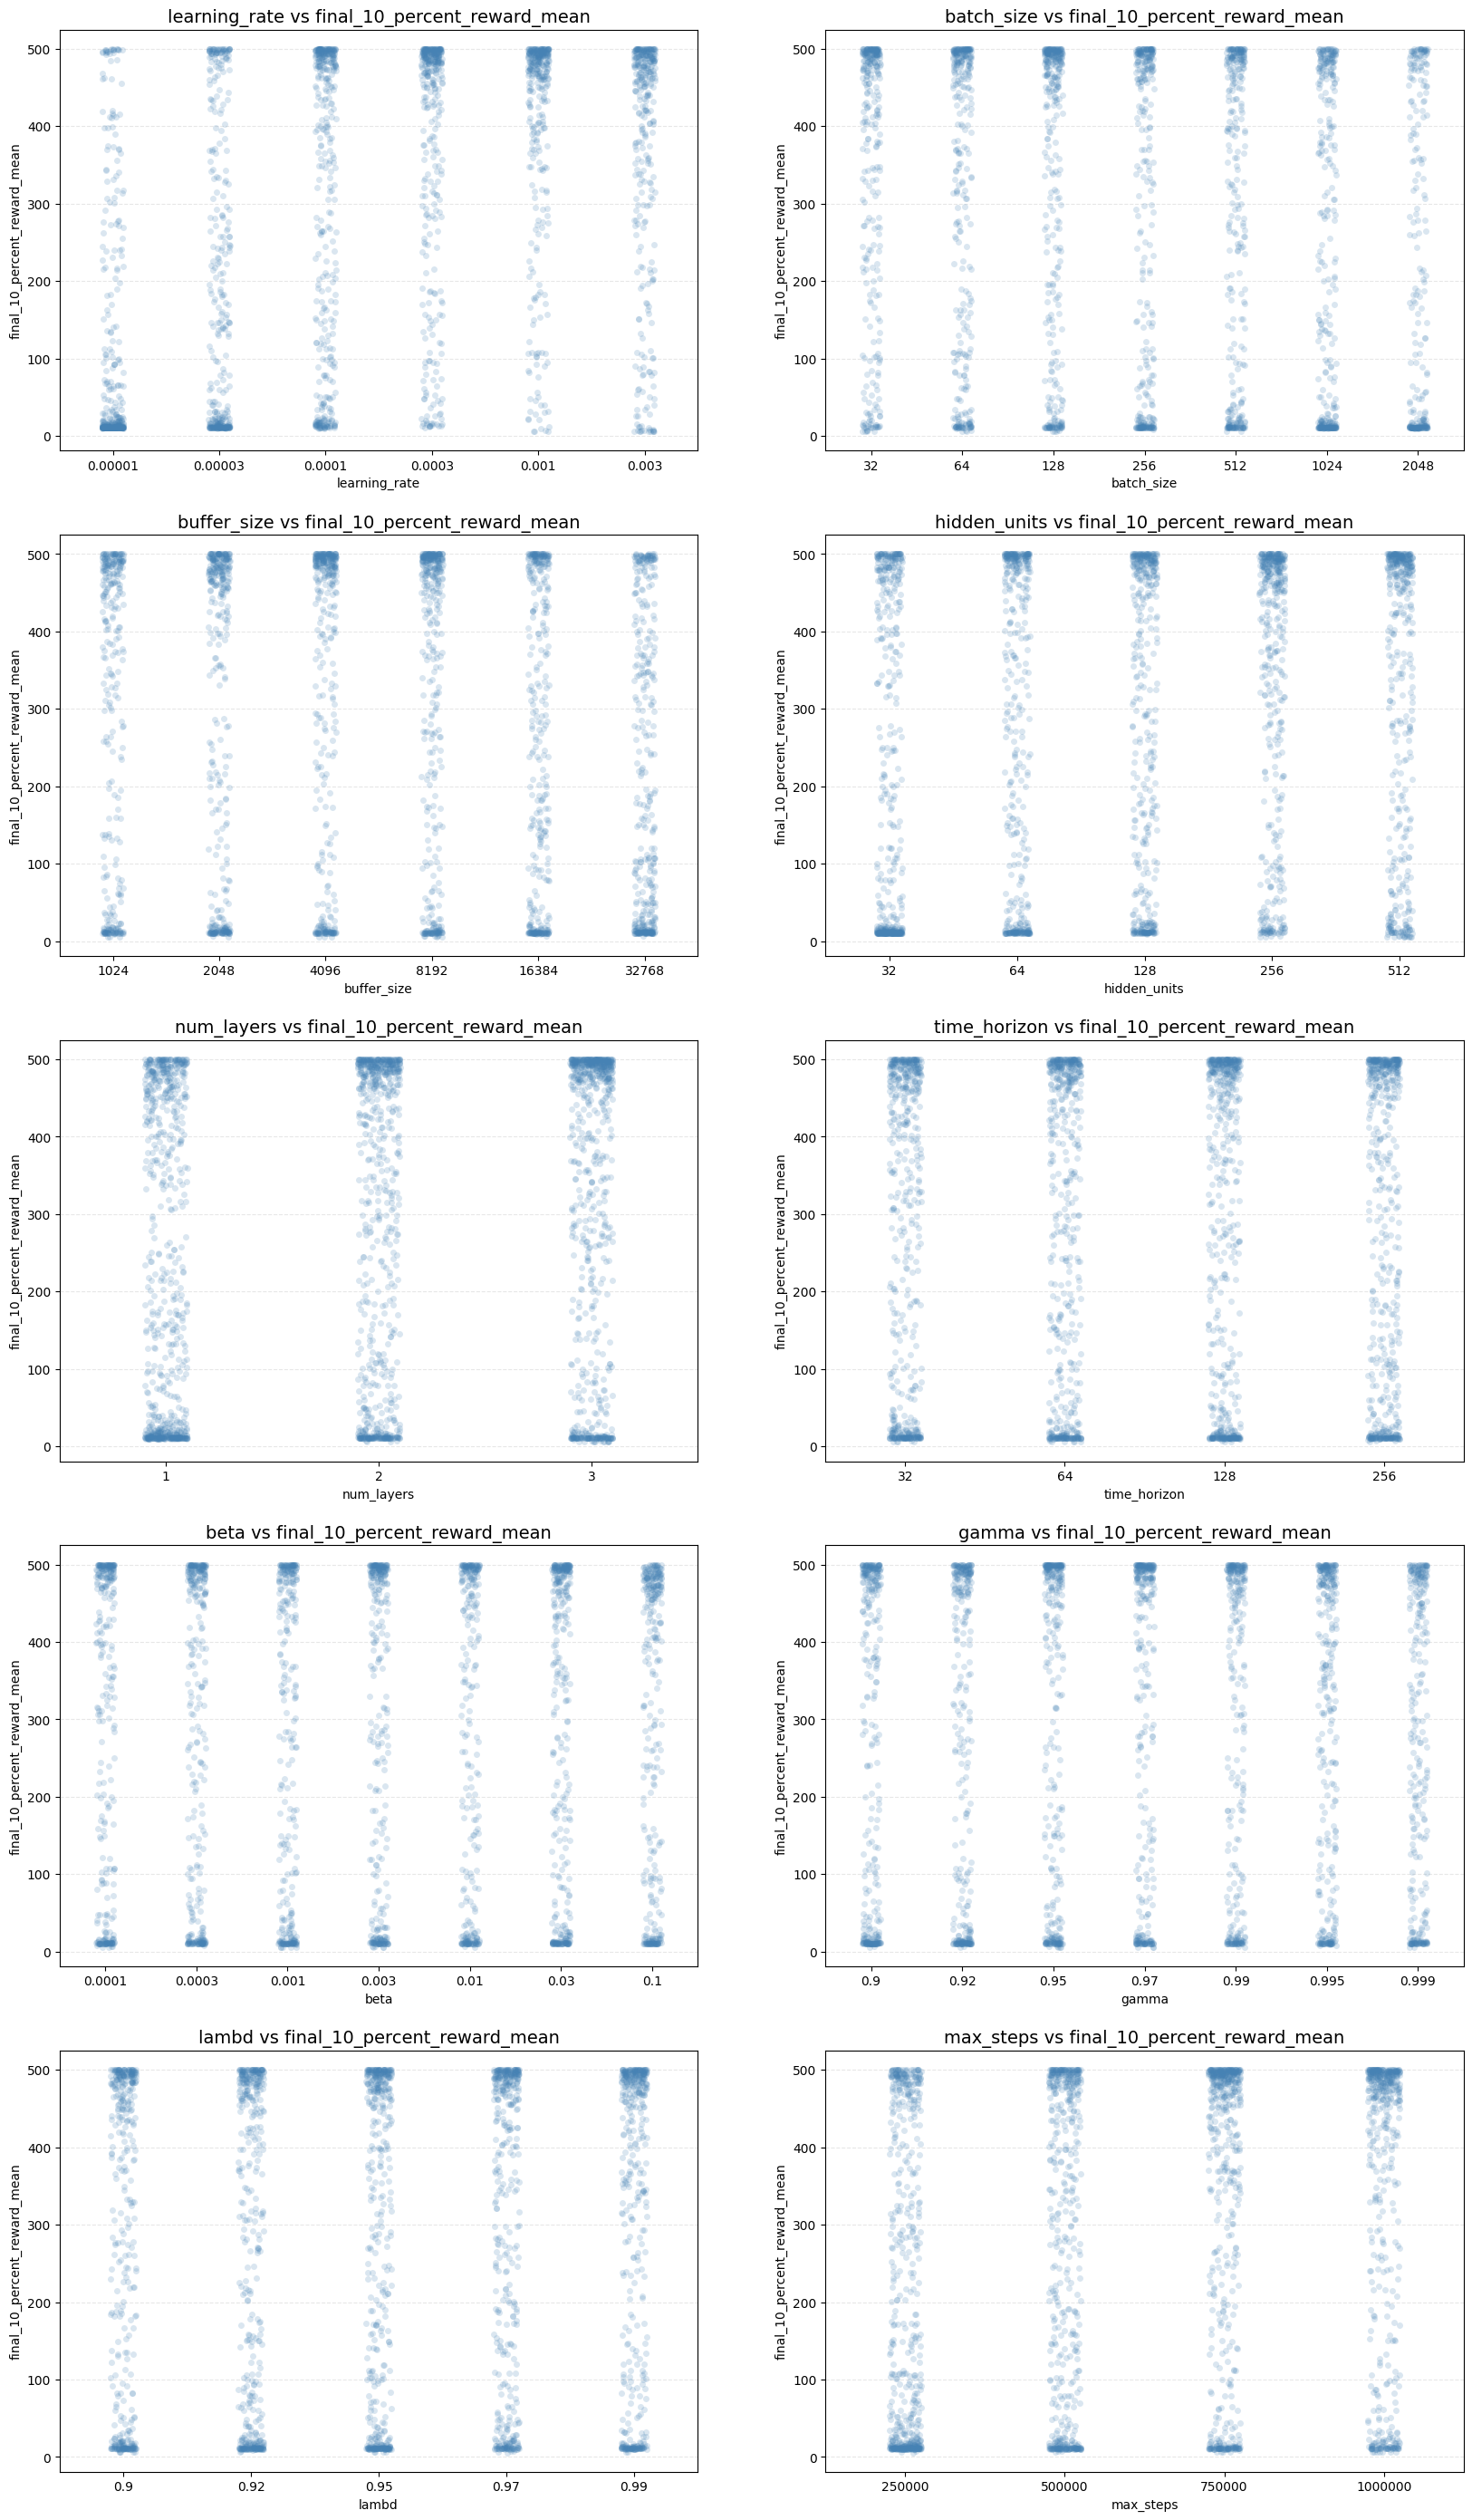

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [92]:

features = feature_cols
target = "final_10_percent_reward_mean"

fig, axes = plt.subplots(5, 2, figsize=(20, 35))
axes = axes.flatten()  


for i, feature in enumerate(features):
    plot = axes[i]

    sorted_values = sorted(df[feature].unique())
    sorted_labels = [f"{val:f}".rstrip('0').rstrip('.') if '.' in f"{val:f}" else f"{val:f}" for val in sorted_values]
    
    plt.figure(figsize=(8, 4))
    
    sns.stripplot(x=df[feature].apply(lambda x: f"{x:f}".rstrip('0').rstrip('.') if '.' in f"{x:f}" else f"{x:f}"), 
                  y=df[target], 
                  data=df, 
                  ax=plot,
                  order=sorted_labels, 
                  alpha=0.2, 
                  jitter=True, #####Set this to False if you want to make it look like the actual scatter plot
                  color='steelblue')
    
    
    plot.set_xticks(range(len(sorted_values)))
    plot.grid(axis='y', linestyle='--', alpha=0.3)
    plot.set_title(f"{feature} vs {target}", fontsize=14)
    plot.set_xlabel(f"{feature}")
    plot.set_ylabel(f"{target}")
    
plt.subplots_adjust(hspace=0.8, wspace=0.3)
plt.show()

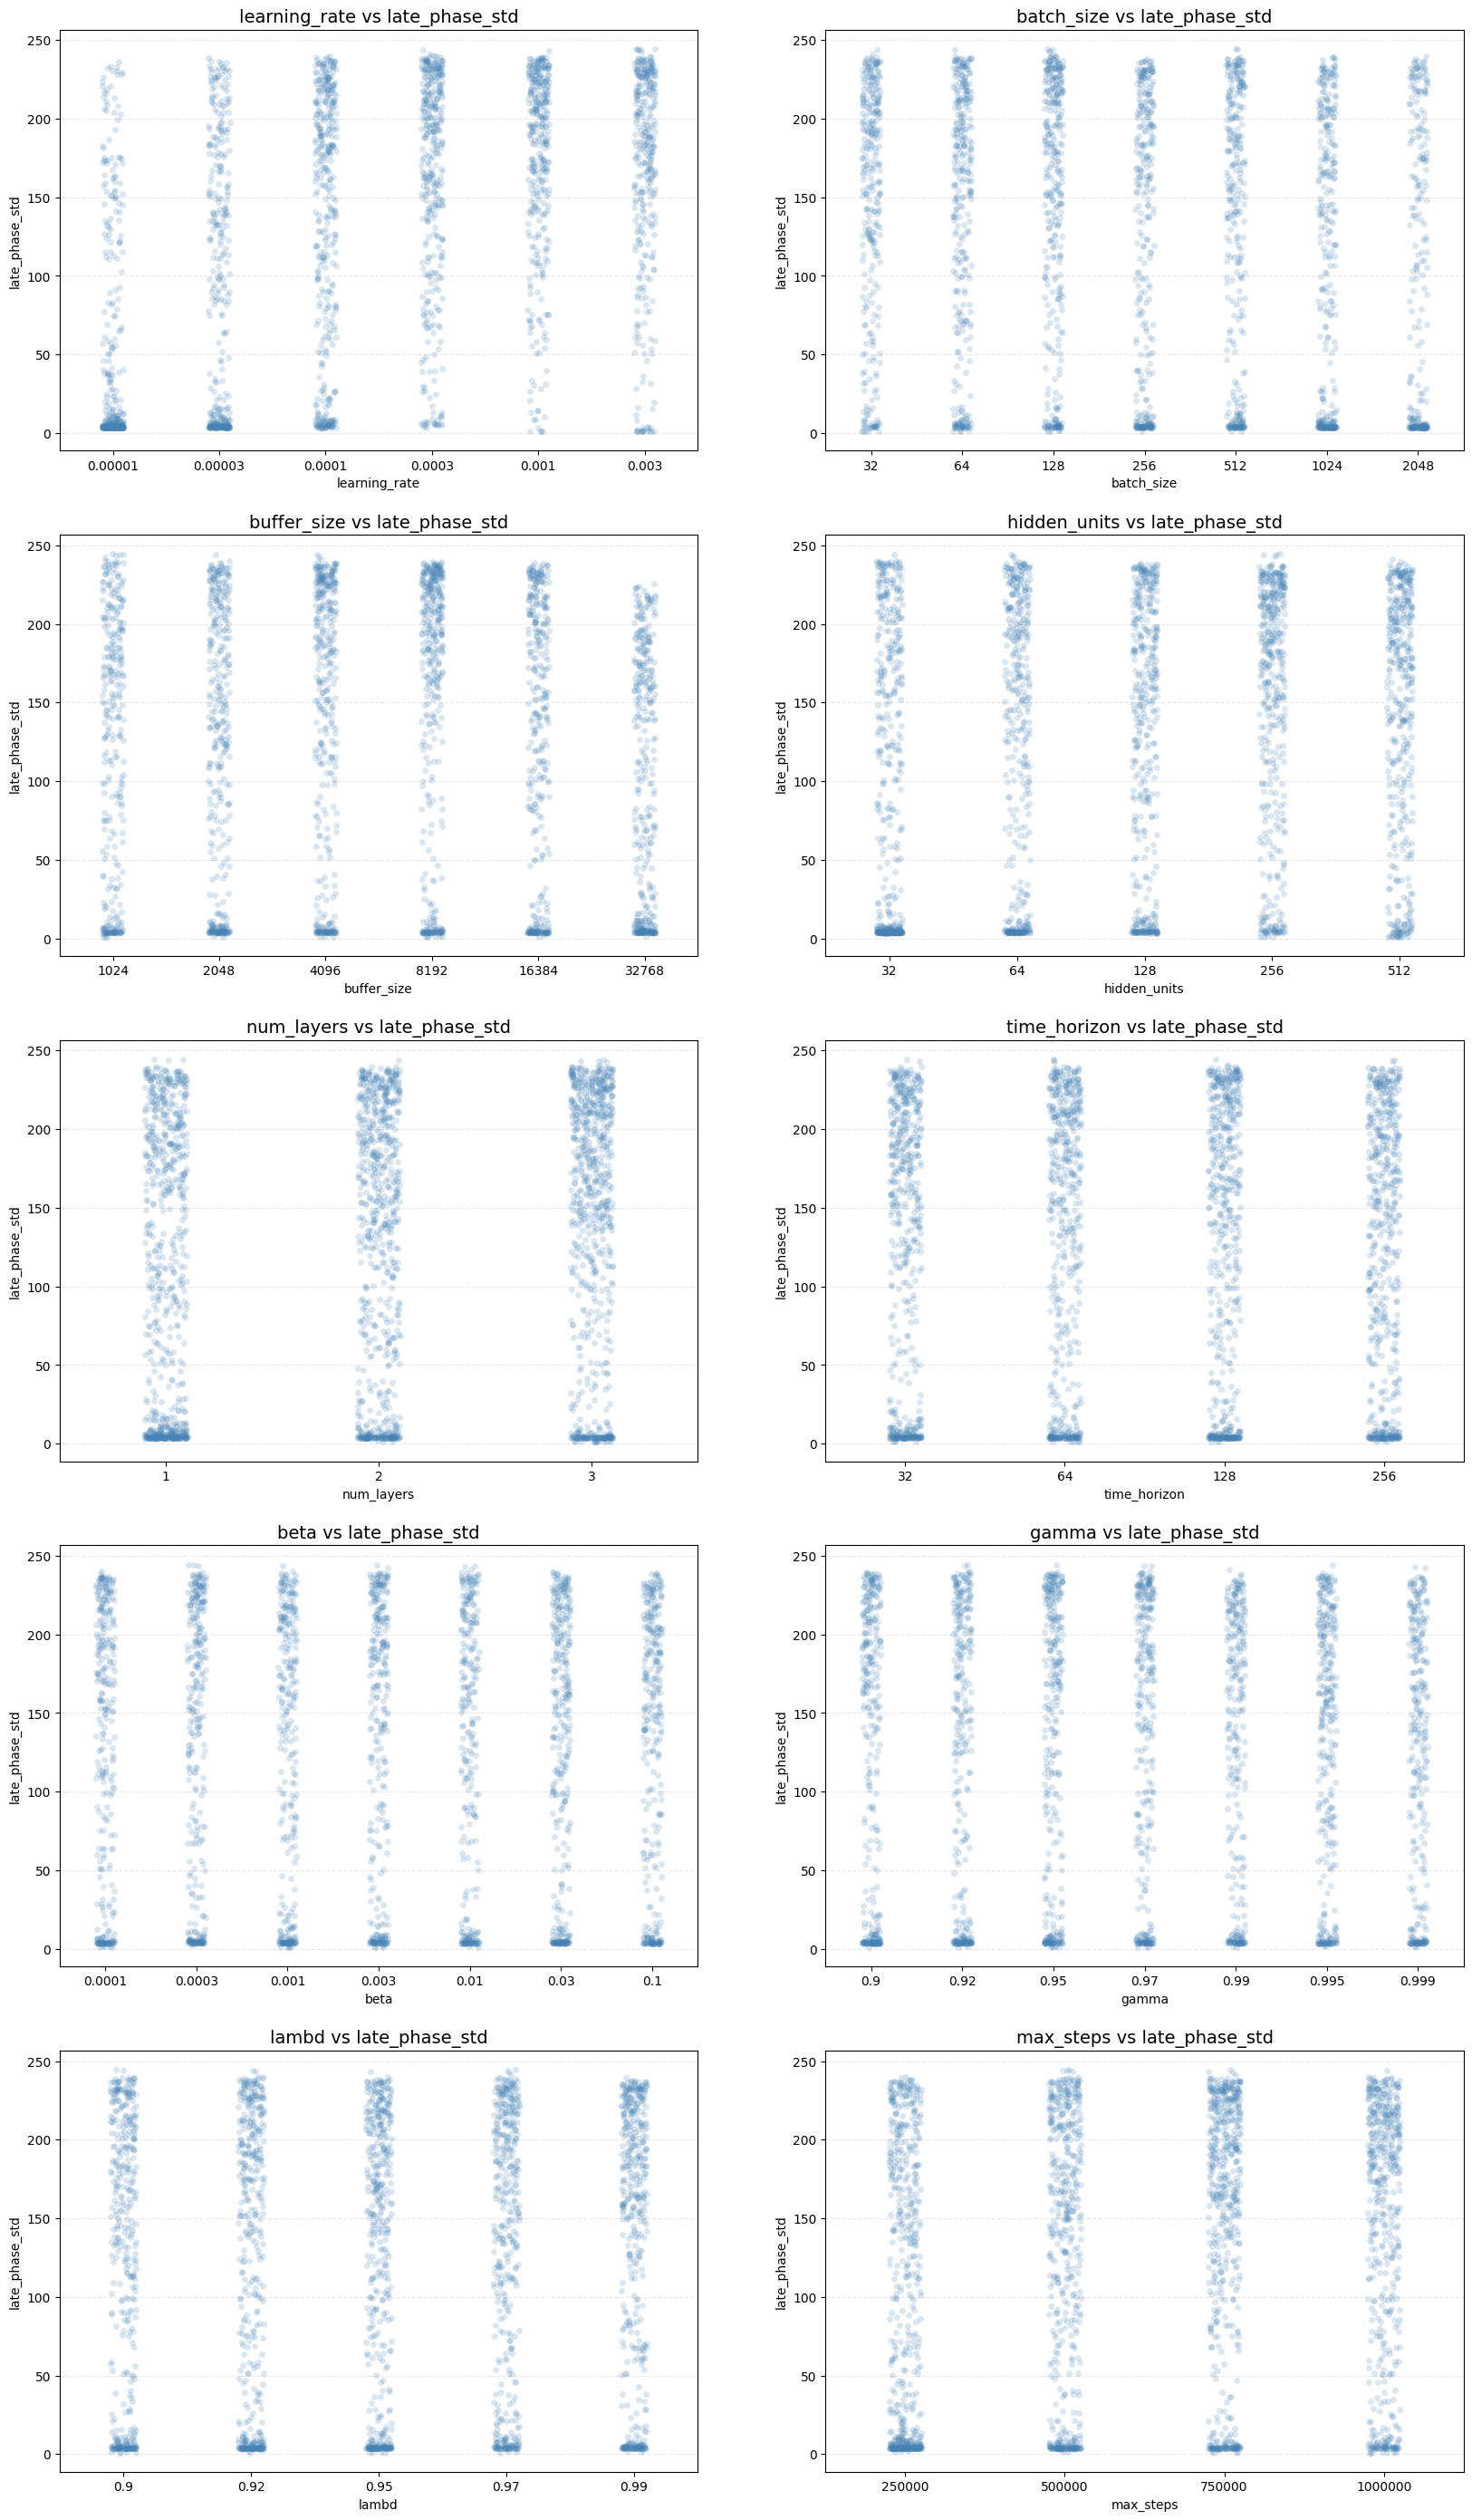

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [93]:

features = feature_cols
target = "late_phase_std"

fig, axes = plt.subplots(5, 2, figsize=(20, 35))
axes = axes.flatten()  


for i, feature in enumerate(features):
    plot = axes[i]

    sorted_values = sorted(df[feature].unique())
    sorted_labels = [f"{val:f}".rstrip('0').rstrip('.') if '.' in f"{val:f}" else f"{val:f}" for val in sorted_values]
    
    plt.figure(figsize=(8, 4))
    
    sns.stripplot(x=df[feature].apply(lambda x: f"{x:f}".rstrip('0').rstrip('.') if '.' in f"{x:f}" else f"{x:f}"), 
                  y=df[target], 
                  data=df, 
                  ax=plot,
                  order=sorted_labels, 
                  alpha=0.2, 
                  jitter=True, #####Set this to False if you want to make it look like the actual scatter plot
                  color='steelblue')
    
    
    plot.set_xticks(range(len(sorted_values)))
    plot.grid(axis='y', linestyle='--', alpha=0.3)
    plot.set_title(f"{feature} vs {target}", fontsize=14)
    plot.set_xlabel(f"{feature}")
    plot.set_ylabel(f"{target}")
    
plt.subplots_adjust(hspace=0.8, wspace=0.3)
plt.show()

5. Feature Correlation (Person A)
- This heatmap should visualize the correlation between all features
- Compute correlation of matrix of all features
- Then visualze by heatmap

The heatmap should look like this Exmaple: 
| | lr | batch | buffer | hidden | layers | time_horizon | beta | gamma | lambda | max_step |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **lr** | 1.00 | 0.01 | -0.02 | 0.10 | 0.05 | ... |... |... |... |... |... |
| **batch** | 0.01 | 1.00 | 0.80 | 0.20 | 0.10 | ... |... |... |... |... |
| **buffer** | -0.02 | 0.80 | 1.00 | 0.15 | 0.05 | ... |... |... |... |... |
|**...**| ... | ... | ... | ... | ... | ... | ... | ... | ... | ... |

Deliverable: 1 heatmap

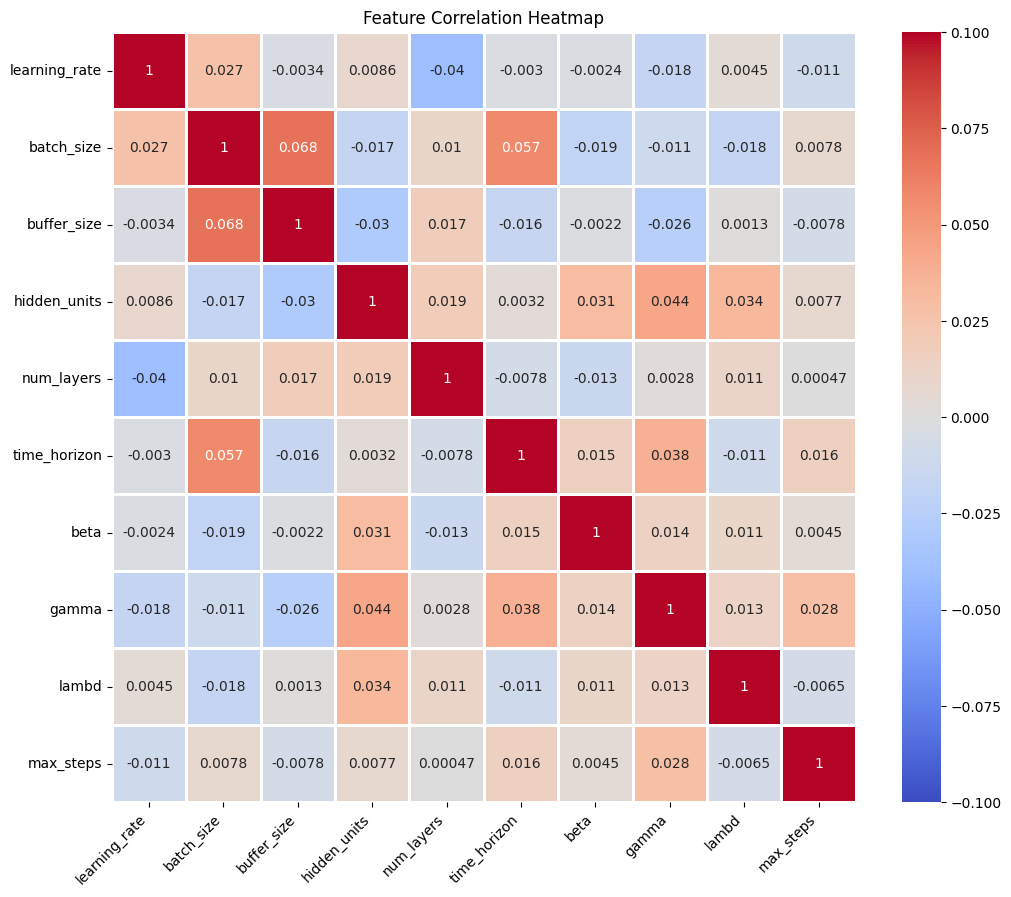

In [ ]:

feature_df = df[feature_cols]
feature_corr_df= feature_df.corr()

plt.figure(figsize=(12, 10))

feature_heatmap =sns.heatmap(feature_corr_df, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1,linewidths= 1 ,linecolor='white', center=0)
feature_heatmap.set_xticklabels(feature_heatmap.get_xticklabels(), rotation=45, ha='right')

plt.title("Feature Correlation Heatmap")
plt.show()

6. Performace vs Stability (Person B)
- To show trade-off between Performance (`final_10_percent_reward_mean`) and Stability (`late_phase_std`)
- Plot a scatter plot:
    - x-axis: `late_phase_std`
    - y-axis: `final_10_percent_reward_mean`

Deliverable: 1 Scatter plot

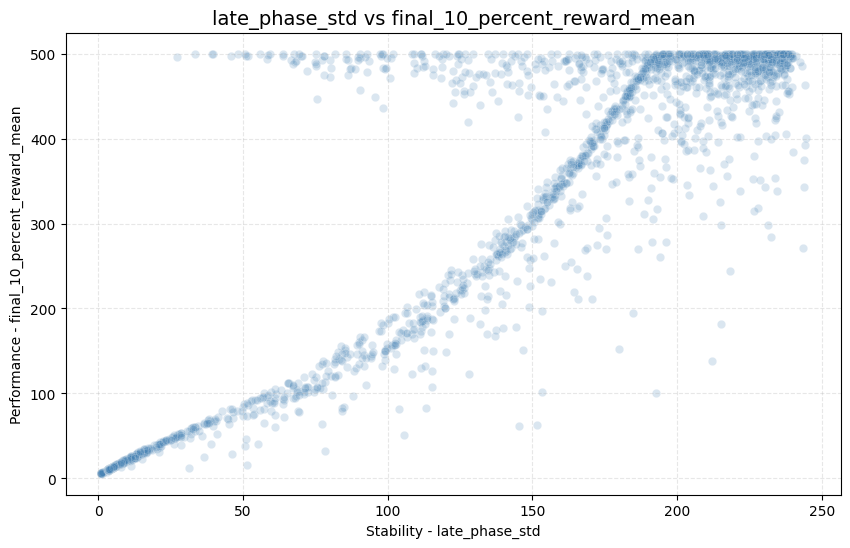

In [96]:
performance = "final_10_percent_reward_mean"
stability = "late_phase_std"

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x=stability, y=performance, alpha=0.2, color='steelblue')

plt.title(f"{stability} vs {performance}", fontsize=14)
plt.xlabel("Stability - late_phase_std")
plt.ylabel("Performance - final_10_percent_reward_mean")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()